### Importing Needy Imports

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Step 1 : Understanding Data

In [3]:
#loading data with needy attributes
df = pd.read_csv("clean_data.csv")

In [4]:
#Sampling data
df.head(5)

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False


In [5]:
#checking data dimmensity
df.shape

(128941, 17)

In [6]:
#checking attribute datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128941 entries, 0 to 128940
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128941 non-null  object 
 1   Date                128941 non-null  object 
 2   Status              128941 non-null  object 
 3   Fulfilment          128941 non-null  object 
 4   Sales Channel       128941 non-null  object 
 5   ship-service-level  128941 non-null  object 
 6   Category            128941 non-null  object 
 7   Size                128941 non-null  object 
 8   Courier Status      128941 non-null  object 
 9   Qty                 128941 non-null  int64  
 10  currency            128941 non-null  object 
 11  Amount              128933 non-null  float64
 12  ship-city           128941 non-null  object 
 13  ship-state          128941 non-null  object 
 14  ship-postal-code    128941 non-null  float64
 15  ship-country        128941 non-nul

### Step 2 : handeling Null Values and Data Transformation

In [7]:
#checking missing values
df.isnull().sum()

Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Category              0
Size                  0
Courier Status        0
Qty                   0
currency              0
Amount                8
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
B2B                   0
dtype: int64

In [8]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

### Step 3 : Univariate Analysis

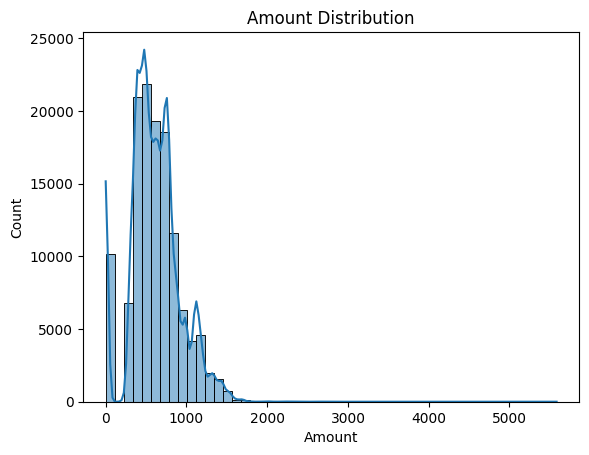

In [9]:
# Distribution of Amount
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Amount Distribution')
plt.show()

<b>Conclusion : </b> <br>
From the histogram we can clearly undersand that the most of the orders are clocked amount between 0-1000

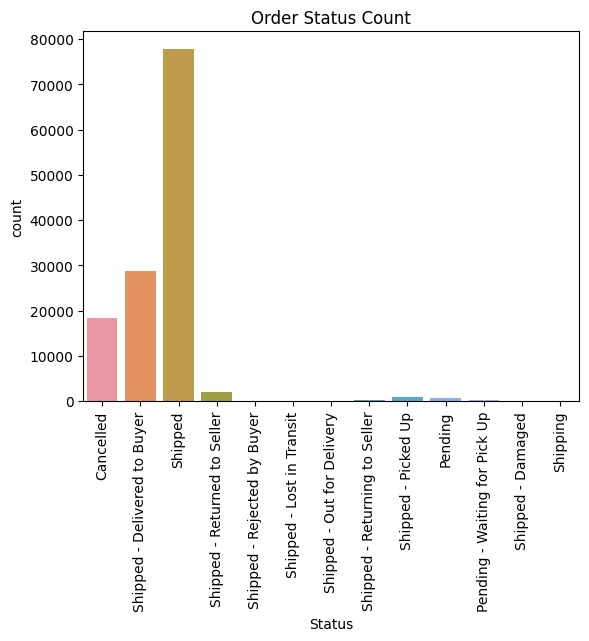

In [10]:
# Order Status Count
sns.countplot(x='Status', data=df)
plt.xticks(rotation=90)
plt.title('Order Status Count')
plt.show()

<b>Conclusion : </b> <br>
From the countplot we can clearly undersand that the most of the orders are either shipped or returned to buyier or being cancelled

### Step 4 : Bivariate Analysis

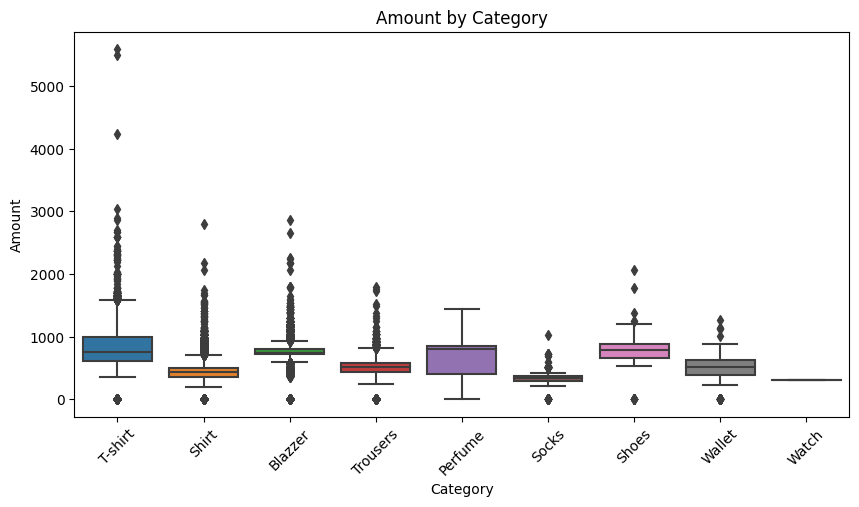

In [11]:
# Amount vs Category
plt.figure(figsize=(10,5))
sns.boxplot(x='Category', y='Amount', data=df)
plt.xticks(rotation=45)
plt.title('Amount by Category')
plt.show()

<b>Conclusion : </b> <br> The boxplot shows high variability in Amount across categories, with T-shirts and Perfumes having extreme outliers, indicating inconsistent pricing

### Step 5 : Multivariate Analysis

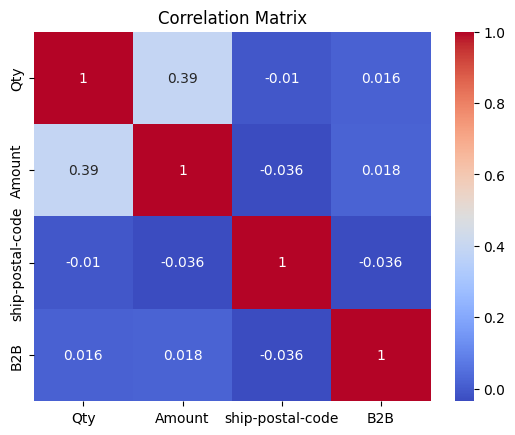

In [12]:
# Correlation between numerical features
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

<b>Concluison : </b>  <br>The correlation matrix shows a moderate positive correlation (0.39) between Qty and Amount, while other features have negligible correlations with each other

### Step 6 :  Feature Engineering

In [13]:
print("Min : ",df['Amount'].min())
print("Q2 : ",df['Amount'].quantile(0.25))
print("Average : ",df['Amount'].mean())
print("Q3 : ",df['Amount'].quantile(0.75))
print("Max : ",df['Amount'].max())

Min :  0.0
Q2 :  413.0
Average :  609.3905225970077
Q3 :  771.0
Max :  5584.0


In [14]:
df['amount_category'] = pd.cut(df['Amount'], bins=[0, 100, 500, 1000, 5000], labels=['Low', 'Medium', 'High', 'Very High'])

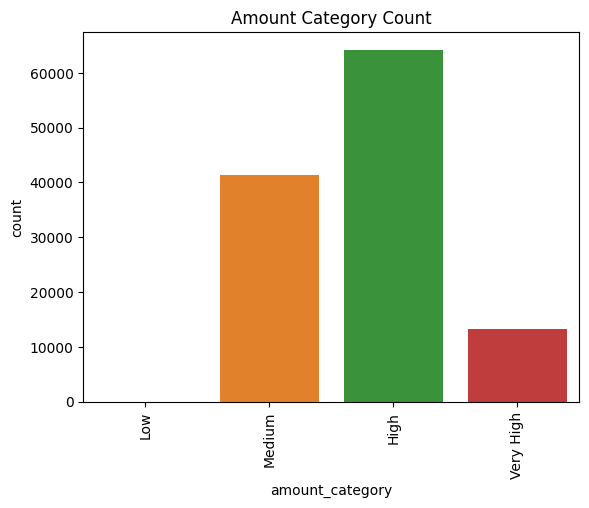

In [15]:
sns.countplot(x='amount_category', data=df)
plt.xticks(rotation=90)
plt.title('Amount Category Count')
plt.show()

<b>Conclusion : </b> <br> from the above count plot we can easily understand that the "High" amount category has the highest count, followed by "Medium", indicating a concentration of orders are in these two categories.

### Step 7 :   Outlier Detection

In [16]:
# Detect outliers using IQR
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]
print(f"Outliers detected in Amount : {outliers.shape[0]}")

# Remove outliers (Optional)
df = df[(df['Amount'] >= lower_bound) & (df['Amount'] <= upper_bound)]


Outliers detected in Amount : 3172


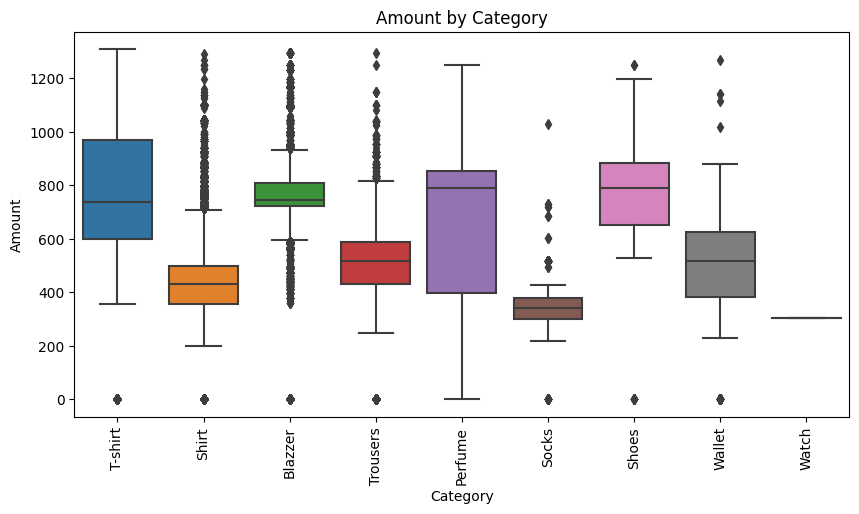

In [17]:
#bivariate analysis between Amount and Category after correcting the outliers in it
plt.figure(figsize=(10,5))
sns.boxplot(x='Category', y='Amount', data=df)
plt.xticks(rotation=90)
plt.title('Amount by Category')
plt.show()